# Pumpkin Analysis

Students: Kailani, Michaela, Priscilla

### Reading in the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pumpkins = pd.read_csv('pumpkins.csv')

In [2]:
pumpkins.shape

(28065, 14)

In [3]:
pumpkins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28065 entries, 0 to 28064
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 28065 non-null  object
 1   place              28065 non-null  object
 2   weight_lbs         28065 non-null  object
 3   grower_name        28065 non-null  object
 4   city               25286 non-null  object
 5   state_prov         28065 non-null  object
 6   country            28065 non-null  object
 7   gpc_site           28065 non-null  object
 8   seed_mother        19522 non-null  object
 9   pollinator_father  17758 non-null  object
 10  ott                24899 non-null  object
 11  est_weight         24899 non-null  object
 12  pct_chart          24899 non-null  object
 13  variety            724 non-null    object
dtypes: object(14)
memory usage: 3.0+ MB


In [4]:
# only keep id's with F or P (pumpkins), then concatenate them together
f_pumpkin = pumpkins[pumpkins['id'].str.contains('F')]
p_pumpkin = pumpkins[pumpkins['id'].str.contains('P')]

pumpkins = pd.concat([f_pumpkin, p_pumpkin]).copy()
pumpkins

,id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,variety
0,2013-F,1,154.50,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.00,20.0,NaN
1,2013-F,2,146.50,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.00,-3.0,NaN
2,2013-F,3,145.00,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.00,26.0,NaN
3,2013-F,4,140.80,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.00,-7.0,NaN
4,2013-F,5,139.00,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.00,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27274,2021-P,DMG,382.70,"Ardron, Simon",Bracknell,England,United Kingdom,Wargrave Nursery Giant Pumpkin Weigh-off,NaN,NaN,0.0,0.00,0.0,NaN
27275,2021-P,DMG,367.00,"Desautels, Jose Pierre",St Alexandre,Quebec,Canada,Potirothon de Gentilly,NaN,NaN,0.0,0.00,0.0,NaN
27276,2021-P,DMG,276.70,"Boschi, Valerio",Pontedera,Tuscany,Italy,Campionato dello Zuccone,230 Geddes,Self,226.0,267.00,4.0,NaN
27277,2021-P,DMG,109.00,"Decola, Gregg",New Haven,Connecticut,United States,Durham Fair Weigh-Off,NaN,NaN,0.0,0.00,0.0,NaN


In [5]:
# taking the year out of id, converting it to a date, and filtering it to year only
pumpkins['year'] = pumpkins['id'].str[0:4]
pumpkins['year'] = pd.to_datetime(pumpkins['year'])
pumpkins['year'] = pumpkins['year'].dt.year

In [6]:
# new type column from id
# rename f and p to field and giant pumpkins
# drop id column because it's not needed
pumpkins['type'] = pumpkins['id'].str[5:6]
pumpkins['type'] = pumpkins['type'].replace({'F':'Field', 'P':'Giant'})
pumpkins = pumpkins.drop(columns = 'id')

In [7]:
# drop variety column. only null values
pumpkins = pumpkins.drop(columns = 'variety')

In [8]:
# there's rows that say what entry number it is. irrelevant, so we removed those
pumpkins = pumpkins[~pumpkins['weight_lbs'].str.contains('Entries')]

In [9]:
# commas in the numeric string columns which was messing with the numeric conversion
pumpkins['weight_lbs'] = pumpkins['weight_lbs'].str.replace(',', '')
pumpkins['ott'] = pumpkins['ott'].str.replace(',', '')
pumpkins['est_weight'] = pumpkins['est_weight'].str.replace(',', '')
pumpkins['pct_chart'] = pumpkins['pct_chart'].str.replace(',', '')

In [10]:
# converting numeric strings to floats
pumpkins['weight_lbs'] = pd.to_numeric(pumpkins['weight_lbs'], errors='coerce')
pumpkins['ott'] = pd.to_numeric(pumpkins['ott'], errors='coerce')
pumpkins['est_weight'] = pd.to_numeric(pumpkins['est_weight'], errors='coerce')
pumpkins['pct_chart'] = pd.to_numeric(pumpkins['pct_chart'], errors='coerce')

In [11]:
# drop place col, we don't need it
pumpkins = pumpkins.drop(columns = 'place')

In [12]:
# the difference between actual weight and estimated weight
pumpkins['change'] = pumpkins['weight_lbs'] - pumpkins['est_weight']
pumpkins['change'].max() # 2158
pumpkins['change'].min() # -10717
pumpkins['weight_lbs'].max() # 2702.9
pumpkins['weight_lbs'].min() # 0.15
pumpkins['est_weight'].max() # 11033
pumpkins['est_weight'].min() # 0

0.0

In [1]:
# function determining the type of estimate
def weight_diff(change): 
    if -25 <= change <= 25: 
        return 'Excellent'
    elif (change >= -100 and change < -25) or (change <= 100 and change > 25):
        return 'Good'
    elif (change >= -300 and change < -100) or (change <= 300 and change > 100):
        return 'Moderate'
    elif (change >= -500 and change < -300) or (change <= 500 and change > 300):
        return 'Poor'
    else: 
        return 'Awful'

pumpkins['change_estimate_ranking'] = pumpkins['change'].apply(weight_diff)

NameError: name 'pumpkins' is not defined

In [2]:
# function determining if it's an over or underestimate
def over_under(change): 
    if change < 0: 
        return 'Under-estimate'
    elif change > 0:
        return 'Over-estimate'
    else: 
        return 'Perfect estimate!'

pumpkins['change_o_u'] = pumpkins['change'].apply(over_under)

NameError: name 'pumpkins' is not defined

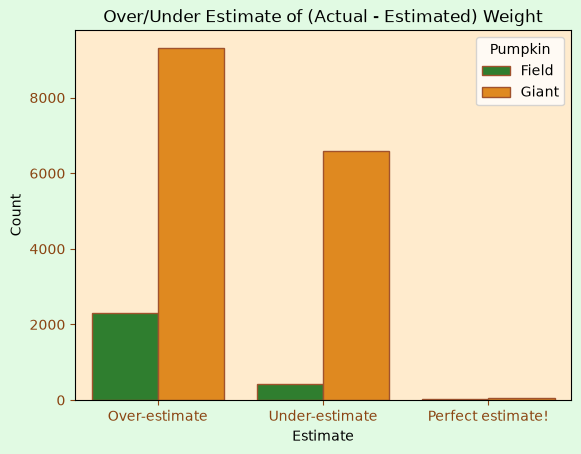

In [ ]:
# graph for good/bad estimate
fig, ax = plt.subplots()
ax.set_facecolor('blanchedalmond')

sns.countplot(
    data = pumpkins, 
    x = 'change_o_u', 
    hue = 'type', 
    palette=["forestgreen", "darkorange"], 
    edgecolor='sienna'
)
plt.xlabel('Estimate')
plt.ylabel('Count')
plt.title('Over/Under Estimate of (Actual - Estimated) Weight')

ax.legend(['Field', 'Giant'], title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#e1fae3')
plt.show()

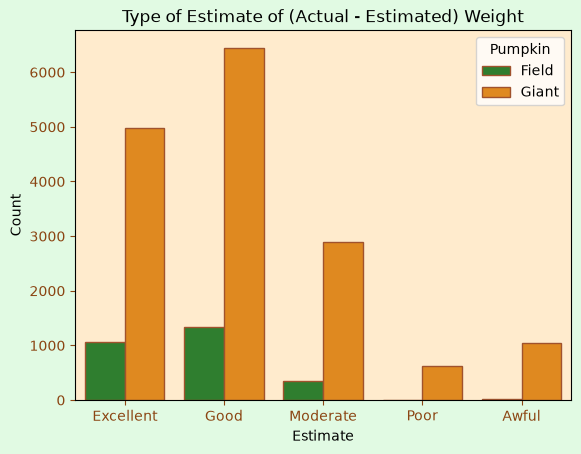

In [ ]:
# graph for over/under estimate
custom_order = ['Excellent', 'Good', 'Moderate', 'Poor', 'Awful']

fig, ax = plt.subplots()
ax.set_facecolor('blanchedalmond')

sns.countplot(
    data = pumpkins, 
    x = 'change_estimate_ranking', 
    hue = 'type', 
    order = custom_order, 
    palette=["forestgreen", "darkorange"], 
    edgecolor='sienna'
)
plt.xlabel('Estimate')
plt.ylabel('Count')
plt.title('Type of Estimate of (Actual - Estimated) Weight')

ax.legend(['Field', 'Giant'], title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#e1fae3')
plt.show()

In [18]:
# gets rid of 'unknown country' and shows the value counts for each country
pumpkins = pumpkins[~pumpkins['country'].str.contains('Unknow')]
pumpkins['country'].value_counts()

country
United States      11463
Canada              2832
Germany             1331
Italy                546
Austria              444
Japan                333
Belgium              294
United Kingdom       212
The Netherlands      205
France               196
Spain                184
Slovenia             158
Finland              122
Switzerland          119
Portugal             114
New Zealand           77
Poland                45
Ireland               21
Australia              5
Luxembourg             1
Name: count, dtype: int64

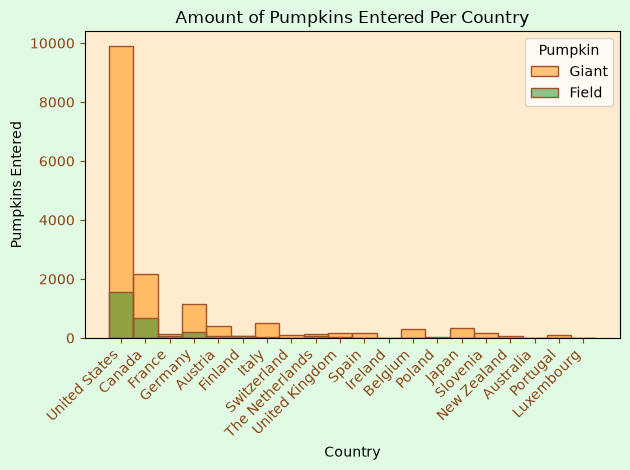

In [74]:
# graph of the number of pumpkins that were entered per country
fig, ax = plt.subplots()
ax.set_facecolor('blanchedalmond')

sns.histplot(
    data = pumpkins, 
    x = 'country', 
    hue = 'type', 
    palette=["forestgreen", "darkorange"], 
    edgecolor='sienna'
)
plt.xlabel('Country', color='black')
plt.ylabel('Pumpkins Entered', color='black')
plt.title('Amount of Pumpkins Entered Per Country')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

ax.legend(['Giant', 'Field'], title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#e1fae3')
plt.show()

In [3]:
# new df with just us as the country
us_pumpkins = pumpkins[pumpkins['country'] == 'United States']

# new variable comparing the mean weights of each state
state_weight = us_pumpkins.groupby(['state_prov', 'type'])['weight_lbs'].mean().sort_values(ascending = False).reset_index()
state_weight.round(2)

# new variable comparing the counts of pumpkins per state
state_count = us_pumpkins.groupby(['state_prov', 'type'])['weight_lbs'].count().sort_values(ascending = False).reset_index()
state_count.round(2)

NameError: name 'pumpkins' is not defined

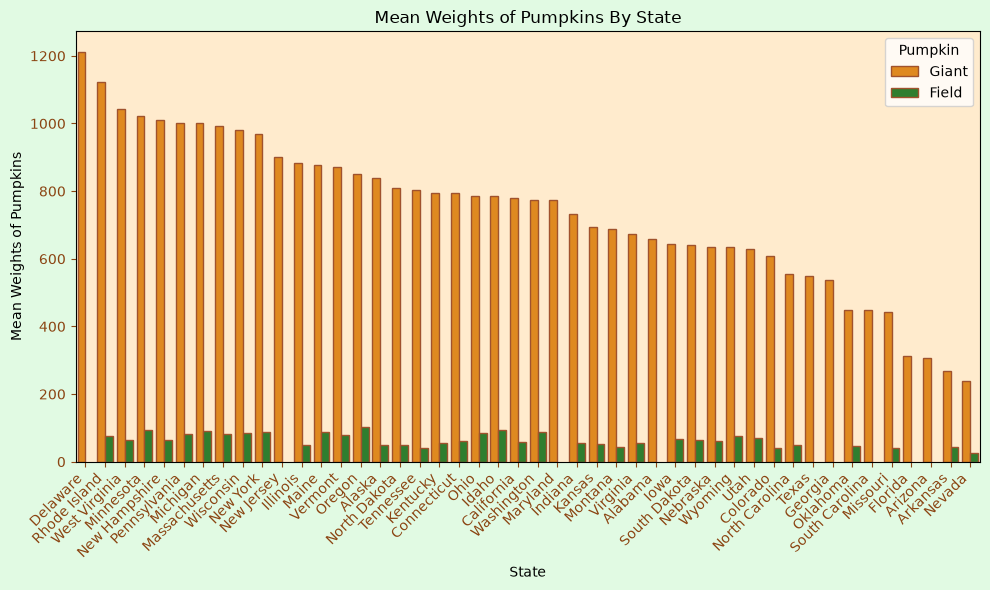

In [75]:
# graph of mean weights of pumpkins per state including type
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('blanchedalmond')

sns.barplot(
    data = state_weight, 
    x = 'state_prov', 
    y = 'weight_lbs', 
    hue = 'type', 
    palette=['darkorange', 'forestgreen'], 
    edgecolor='sienna'
)
plt.xlabel('State')
plt.ylabel('Mean Weights of Pumpkins')
plt.title('Mean Weights of Pumpkins By State')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

ax.legend(title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#e1fae3')
plt.show()

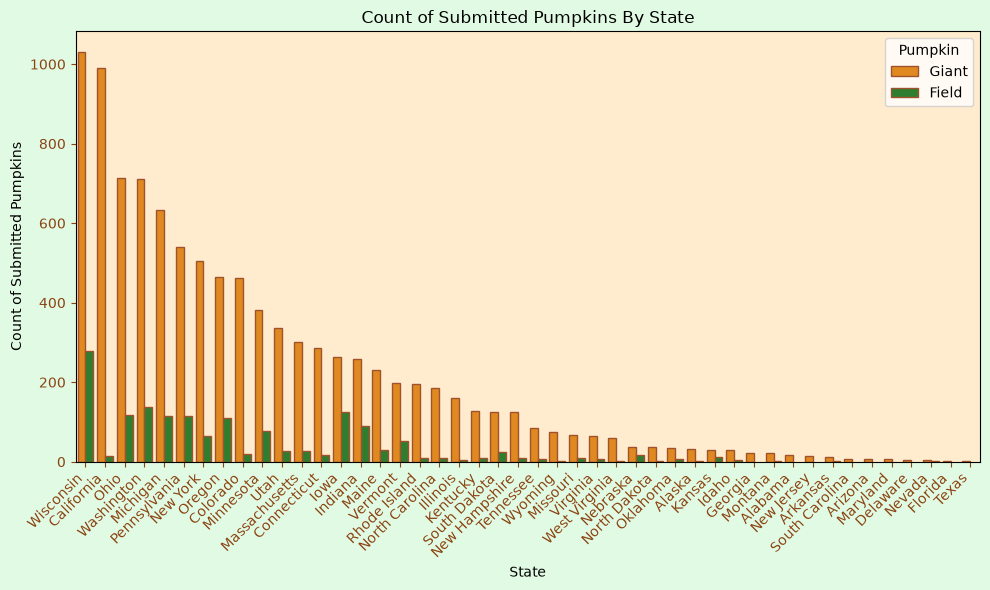

In [76]:
# graph of counts of pumpkins per state including type
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('blanchedalmond')

sns.barplot(
    data = state_count, 
    x = 'state_prov', 
    y = 'weight_lbs', 
    hue = 'type', 
    palette=['darkorange', 'forestgreen'], 
    edgecolor='sienna'
)
plt.xlabel('State')
plt.ylabel('Count of Submitted Pumpkins')
plt.title('Count of Submitted Pumpkins By State')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

ax.legend(title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#e1fae3')
plt.show()